In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb

In [42]:
url = "https://drive.google.com/uc?id=1AMBzflTbushZN3zzZL-pl390QCm3e5Qx"

df = pd.read_csv(url)

df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [43]:
print(df.isnull().sum())

df.dropna(inplace=True)

Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64


In [44]:
le = LabelEncoder()

categorical_cols = [
'Area Name',
'Road/Intersection Name',
'Weather Conditions',
'Roadwork and Construction Activity'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [45]:
df['Date'] = pd.to_datetime(df['Date'])

df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['weekday'] = df['Date'].dt.weekday

df.drop("Date", axis=1, inplace=True)

In [46]:
def congestion_category(x):

    if x < 100:
        return "Low"
    
    elif x < 300:
        return "Medium"
    
    else:
        return "High"

df['Congestion Level'] = df['Congestion Level'].apply(congestion_category)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Congestion Level'] = le.fit_transform(df['Congestion Level'])

In [48]:
df['Congestion Level'].unique()

array([1, 0])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
X = df.drop("Congestion Level", axis=1)
y = df["Congestion Level"]

In [51]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.9586129753914989


In [52]:
model = xgb.XGBClassifier()

model.fit(X_train, y_train)

pred_xgb = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))

XGBoost Accuracy: 0.9530201342281879


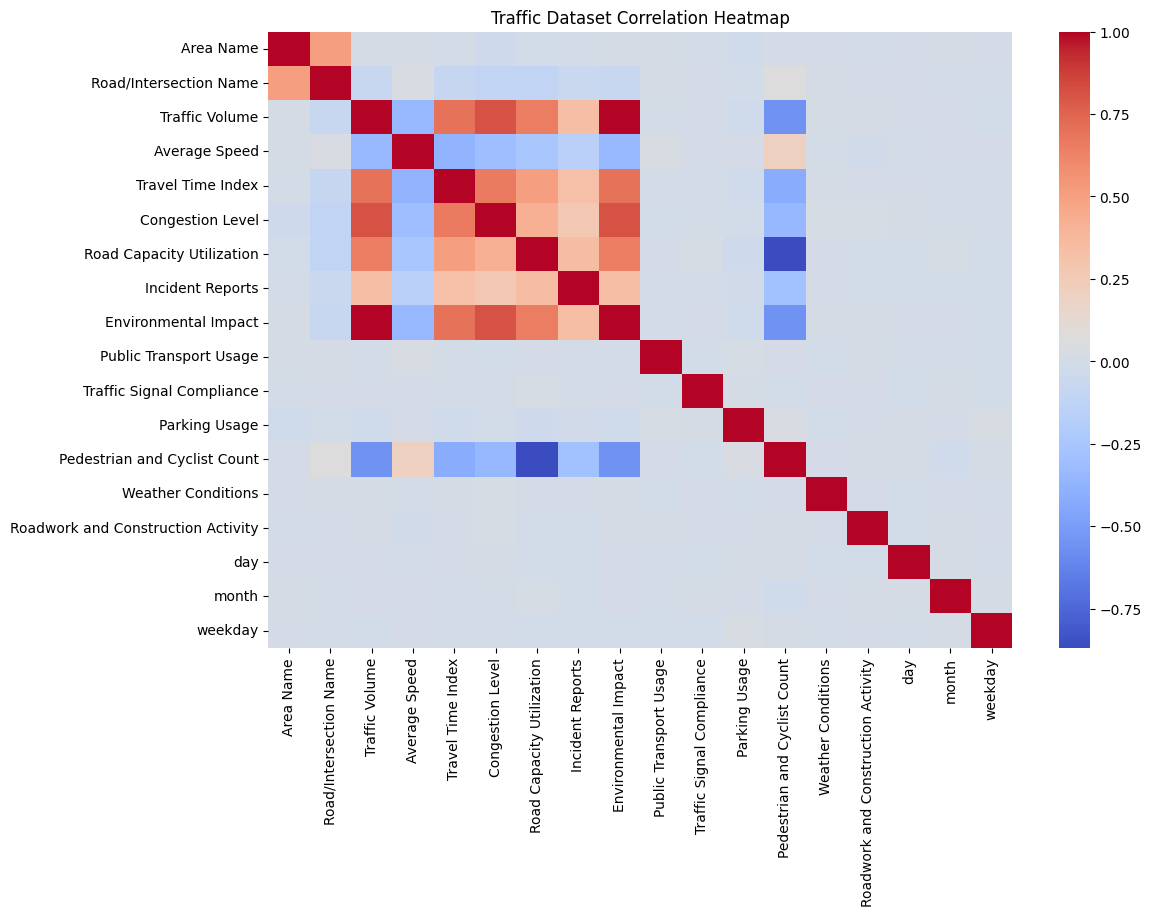

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Traffic Dataset Correlation Heatmap")
plt.show()

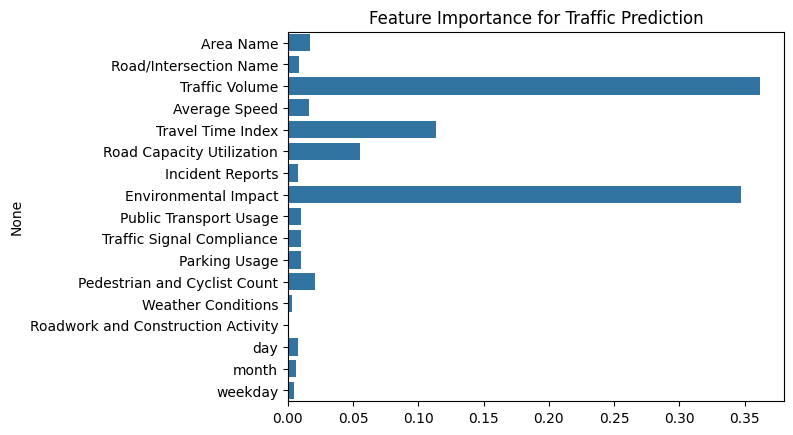

In [54]:
importances = rf.feature_importances_

features = X.columns

sns.barplot(x=importances, y=features)

plt.title("Feature Importance for Traffic Prediction")
plt.show()

In [55]:
import joblib

joblib.dump(rf, "traffic_model.pkl")

['traffic_model.pkl']